In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/macbookair/Downloads/Bank Customer Churn Prediction.csv")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Basic Data Overview

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:")
print(df.duplicated().sum())

df.info()

Shape: (10000, 12)

Columns:
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

Missing values:
customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

Duplicated rows:
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure     

In [3]:
# Standardize column names

df.columns = df.columns.str.lower().str.replace(" ", "_")

df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Churn Rate

churn_rate = df["churn"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 20.37%


In [5]:
# Churn by Country

country_churn = df.groupby("country")["churn"].mean().sort_values(ascending=False) * 100

country_churn

country
Germany    32.443204
Spain      16.673395
France     16.154767
Name: churn, dtype: float64

In [6]:
# Churn by Gender

gender_churn = df.groupby("gender")["churn"].mean().sort_values(ascending=False) * 100

gender_churn

gender
Female    25.071539
Male      16.455928
Name: churn, dtype: float64

In [7]:
# Churn by Active Member Status

active_churn = df.groupby("active_member")["churn"].mean().sort_values(ascending=False) * 100

active_churn

active_member
0    26.850897
1    14.269074
Name: churn, dtype: float64

In [8]:
# Average Customer Profile: Churned vs Retained

profile_summary = df.groupby("churn")[[
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "estimated_salary"
]].mean()

profile_summary

,credit_score,age,tenure,balance,products_number,estimated_salary
churn,,,,,,
0,651.853196,37.408389,5.033279,72745.296779,1.544267,99738.391772
1,645.351497,44.837997,4.932744,91108.539337,1.475209,101465.677531


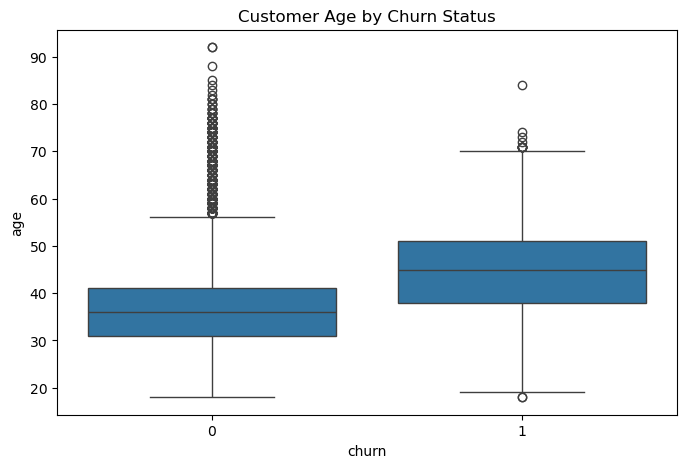

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn",
    y="age",
    data=df
)

plt.title("Customer Age by Churn Status")
plt.show()

### Insight 1: Older Customers Are More Likely to Churn

Customers who churned tend to be older than retained customers.

The median age of churned customers is approximately 45 years, while retained customers have a median age around 35 years.

This suggests that older customers may require more targeted retention strategies.

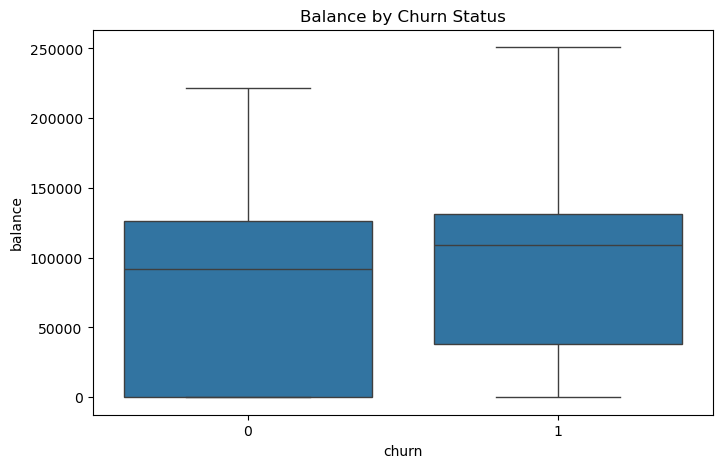

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="churn",
    y="balance",
    data=df
)

plt.title("Balance by Churn Status")
plt.show()

### Insight 2: High-Balance Customers Show Higher Churn Risk

Customers who left the bank generally have higher account balances than retained customers.

This finding is important because losing high-balance customers can significantly impact revenue.

The bank should prioritize retention efforts for high-value customers.

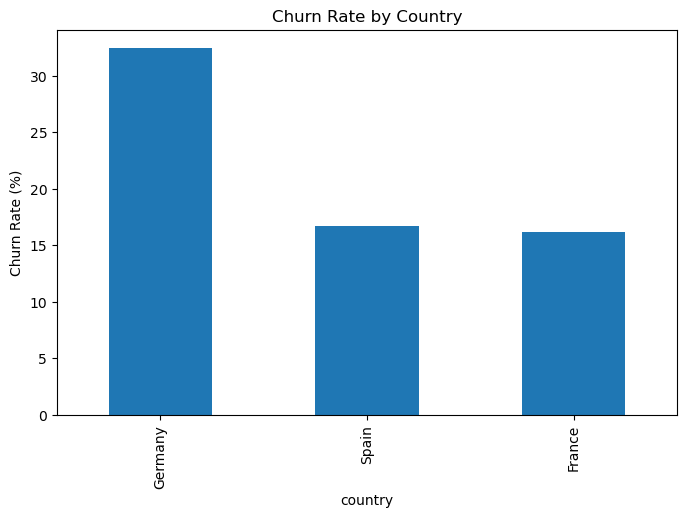

In [11]:
country_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Country")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight 3: Germany Has the Highest Churn Rate

German customers have the highest churn rate at approximately 32%.

This is nearly double the churn rate observed in France and Spain.

Further investigation is needed to understand customer dissatisfaction in Germany.

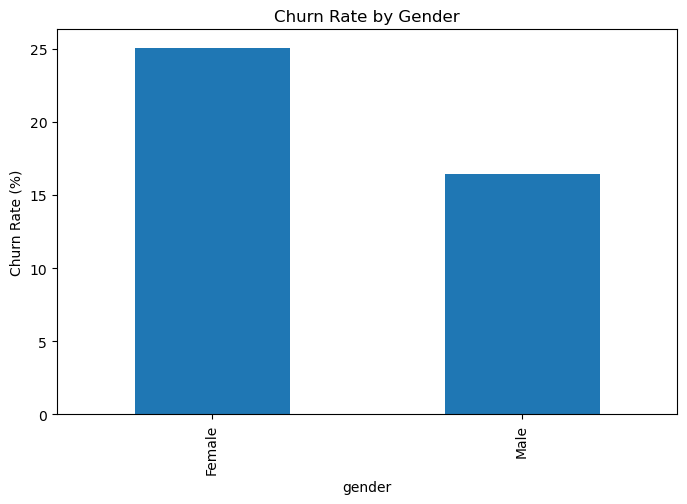

In [12]:
gender_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate (%)")

plt.show()

### Insight 4: Female Customers Churn More Frequently

Female customers exhibit a churn rate of approximately 25%, compared with 16% for male customers.

This indicates that customer experience and retention strategies may affect genders differently.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [14]:
df_model = df.copy()

le = LabelEncoder()

df_model["country"] = le.fit_transform(df_model["country"])
df_model["gender"] = le.fit_transform(df_model["gender"])

df_model.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [15]:
X = df_model.drop(
    ["customer_id", "churn"],
    axis=1
)

y = df_model["churn"]

print(X.shape)
print(y.shape)

(10000, 10)
(10000,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 10)
(2000, 10)


In [17]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    pred
)

print("Accuracy:", accuracy)

Accuracy: 0.816


In [19]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.19      0.29       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.79      0.82      0.78      2000



## Predictive Modeling Results

A Logistic Regression model was built to predict customer churn.

Model Performance:

- Accuracy: 81.6%
- Precision (Churn): 60%
- Recall (Churn): 19%
- F1 Score (Churn): 29%

Key Findings:

The model achieved acceptable overall accuracy. However, recall for churned customers was relatively low, indicating that many churn cases were not correctly identified.

This suggests that further model improvements such as class balancing techniques, feature engineering, or advanced algorithms may improve churn prediction performance.

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Accuracy: 0.8645
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.57       393

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



## Model Comparison

Two machine learning models were evaluated:

### Logistic Regression
- Accuracy: 81.6%
- Recall: 19%
- F1 Score: 0.29

### Random Forest
- Accuracy: 86.45%
- Recall: 47%
- F1 Score: 0.57

### Conclusion

Random Forest significantly outperformed Logistic Regression in identifying churned customers.

The model achieved higher accuracy and substantially improved recall, making it a more effective solution for customer churn prediction.

# Final Business Insights

1. Older customers are more likely to churn.

2. Customers with higher account balances show higher churn rates.

3. Germany has the highest customer churn rate among all countries.

4. Female customers exhibit a higher churn rate than male customers.

5. Random Forest outperformed Logistic Regression for churn prediction.

### Recommendation

The bank should focus retention efforts on:

- Older customers
- High-balance customers
- Customers located in Germany
- Female customer segments

Targeted retention campaigns may help reduce future customer churn.